In this notebook we compute the matter power spectrum for ultralight **scalar** dark matter (SFDM, via CLASS's `scf` sector) and save the results to disk so they can be loaded later by the VFDM notebook for comparison. The plots here show only the SFDM vs CDM percentage difference.

Data files are saved as `../../SFDM_data/delta_scf/Pk_scf_errors_m=<tail>_z=<z>` with two columns: `k [h/Mpc]` and `P(k) [(Mpc/h)^3]`. The mass tag `<tail>` is the last 3 characters of `str(mass)` (e.g. `-25` for `1.e-25`), matching the convention expected by the VFDM notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'tol_thermo_integration': 1.0e-6,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,
                 'Omega_cdm' : omega_cdm/h_planck**2, 'Omega_scf' : 0.,
                 'h' : h_planck,
                 'A_s' : As,
                 'n_s':ns,
                 'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl,pCl, mPk','gauge':'synchronous',
                 'ic' : 'ad', 'z_pk' : '0,20',
                 'modes' : 's', 'recombination' : 'RECFAST'}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()

# SFDM cosmology: replace (almost all of) the CDM with a scalar field.
frac = 1-1.e-6
common_settings  = {
            'h' : h_planck,
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_scf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_scf' : 'yes',
            'scf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl,mPk',
            'ic' : 'ad', 'z_pk' : '0,20',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'modes' : 's',
            'recombination' : 'RECFAST'
            }
common_settings.update(precision_settings)

As a benchmark, let's define the LCDM cosmology.

## Porcentual Errors

### Small Masses

In [4]:
small_masses = [1.e-25, 1.e-24, 1.e-23, 1.e-22]
small_masses_Mpc = [mass*1.56373846613383*1.e29 for mass in small_masses]  # Mpc^-1
k_smallm_max = 1.e1
z_save = [0, 20]                       # redshifts at which we save P(k)
kk_small = np.logspace(-3, 1, 5000)    # k grid in h/Mpc (must match VFDM notebook)

lcdm_smallm = Class()
lcdm_smallm.set(lcdm_settings)
lcdm_smallm.set({'P_k_max_h/Mpc': k_smallm_max})
lcdm_smallm.compute()

cosmo_small_mass = {}
for m in range(len(small_masses)):

    cosmo_small_mass[m] = Class()
    cosmo_small_mass[m].set(common_settings)
    cosmo_small_mass[m].set({'P_k_max_h/Mpc': k_smallm_max})
    cosmo_small_mass[m].set({'scf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % small_masses[m]})
    cosmo_small_mass[m].compute()

    h_scf = cosmo_small_mass[m].h()

    for z0 in z_save:
        Pk_scf = np.array([cosmo_small_mass[m].pk(k * h_scf, z0) * h_scf**3 for k in kk_small])
        np.savetxt('../../SFDM_data/delta_scf/Pk_scf_errors_m=%s_z=%s' % (str(small_masses[m])[-3:], str(z0)),
                   np.column_stack([kk_small, Pk_scf]))

    print(small_masses[m])

1e-25
1e-24
1e-23
1e-22


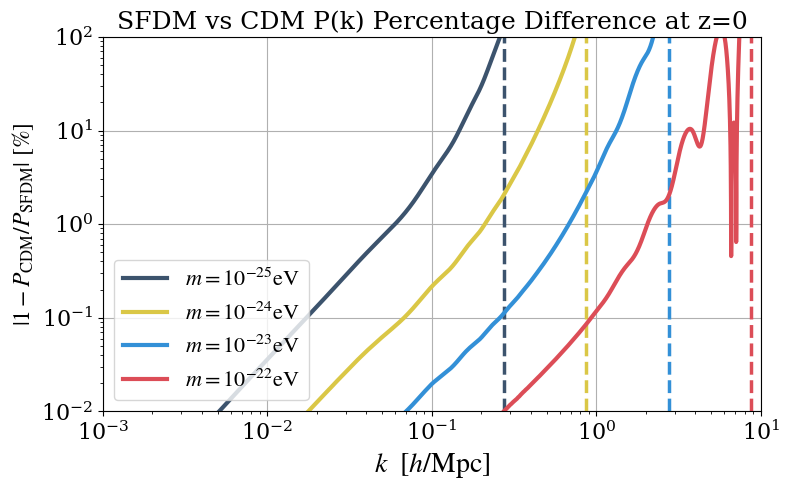

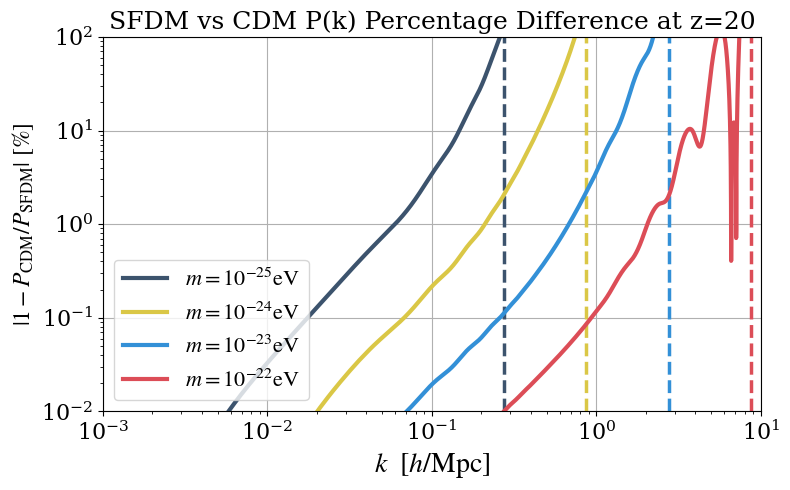

In [5]:
def Pk_scalar_porcentual_small_m(z0):
    colors_plot = ['#3C536D', '#DAC746', '#3390D7', '#DC4D57']
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.grid()

    for m in range(len(small_masses)):

        kk = kk_small  # k in h/Mpc (same grid as VFDM notebook)

        h_scf = cosmo_small_mass[m].h()
        h_lcdm = lcdm_smallm.h()

        # Jeans-like scale where H = m (in physical units).
        background = cosmo_small_mass[m].get_background()
        background_a = 1 / (1 + background['z'])
        background_H_over_m = background['H [1/Mpc]'] / small_masses_Mpc[m]
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)
        kJ = a_osc * np.sqrt(small_masses_Mpc[m] * H_osc) / h_scf

        Pk_scf  = np.array([cosmo_small_mass[m].pk(k * h_scf,  z0) * h_scf**3  for k in kk])
        Pk_lcdm = np.array([lcdm_smallm.pk(k * h_lcdm, z0) * h_lcdm**3 for k in kk])

        ax.loglog(kk, 100 * np.abs(1 - (Pk_lcdm / Pk_scf)),
                  color=colors_plot[m],
                  label=r'$m=10^{%s}\rm{eV}$' % str(small_masses[m])[-3:], lw=3)
        ax.axvline(kJ, color=colors_plot[m], linestyle='dashed', lw=2.5)

    ax.set_ylim([1.e-2, 1.e2])
    ax.set_xlim([1.e-3, 1.e1])
    ax.set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=20)
    ax.set_ylabel(r'$|1 - P_{\rm CDM}/P_{\rm SFDM}|\ [\%]$', size=17)
    ax.set_title('SFDM vs CDM P(k) Percentage Difference at z=%s' % str(z0), size=18)
    ax.legend(loc='lower left', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_Porcentual_errors_small_masses_z=%s.pdf' % str(z0), format='pdf')
    plt.savefig('../../Figures/Pk_Porcentual_errors_small_masses_z=%s.png' % str(z0), format='png')
    plt.show()

Pk_scalar_porcentual_small_m(0)
Pk_scalar_porcentual_small_m(20)

### Big Masses

In [6]:
big_masses = [1.e-21, 1.e-20, 1.e-19, 1.e-18]
big_masses_Mpc = [mass*1.56373846613383*1.e29 for mass in big_masses]  # Mpc^-1
k_bigm_max = 1.e3
kk_big = np.logspace(0, np.log10(k_bigm_max), 5000)  # k grid in h/Mpc (must match VFDM notebook)

lcdm_bigm = Class()
lcdm_bigm.set(lcdm_settings)
lcdm_bigm.set({'P_k_max_h/Mpc': k_bigm_max})
lcdm_bigm.compute()

cosmo_big_mass = {}
for m in range(len(big_masses)):

    cosmo_big_mass[m] = Class()
    cosmo_big_mass[m].set(common_settings)
    cosmo_big_mass[m].set({'P_k_max_h/Mpc': k_bigm_max})
    cosmo_big_mass[m].set({'scf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % big_masses[m]})
    cosmo_big_mass[m].compute()

    h_scf = cosmo_big_mass[m].h()

    for z0 in z_save:
        Pk_scf = np.array([cosmo_big_mass[m].pk(k * h_scf, z0) * h_scf**3 for k in kk_big])
        np.savetxt('../../SFDM_data/delta_scf/Pk_scf_errors_m=%s_z=%s' % (str(big_masses[m])[-3:], str(z0)),
                   np.column_stack([kk_big, Pk_scf]))

    print(big_masses[m])

1e-21
1e-20
1e-19
1e-18


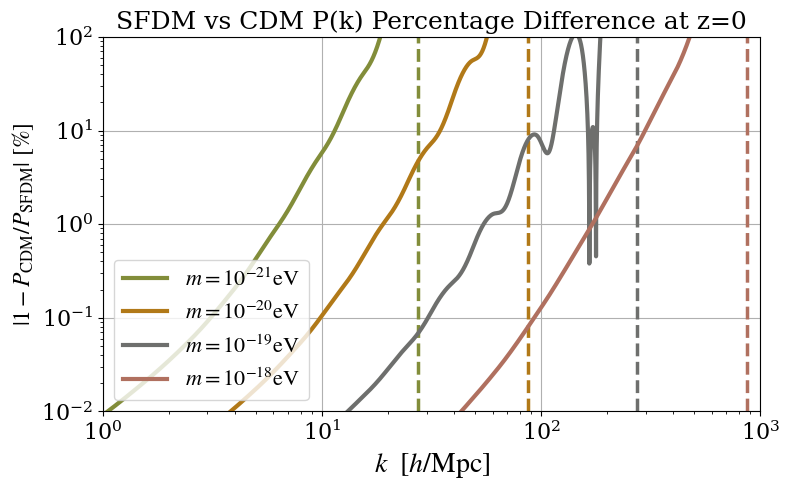

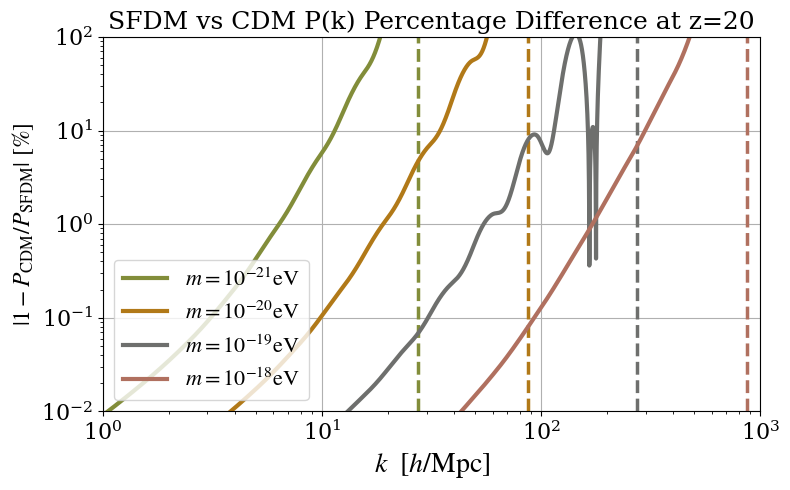

In [7]:
def Pk_scalar_porcentual_big_m(z0):
    color_plots = ['#828D3A', '#B17918', '#6E6F6D', '#B0705F']
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.grid()

    for m in range(len(big_masses)):

        kk = kk_big  # k in h/Mpc (same grid as VFDM notebook)

        h_scf = cosmo_big_mass[m].h()
        h_lcdm = lcdm_bigm.h()

        background = cosmo_big_mass[m].get_background()
        background_a = 1 / (1 + background['z'])
        background_H_over_m = background['H [1/Mpc]'] / big_masses_Mpc[m]
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)
        kJ = a_osc * np.sqrt(big_masses_Mpc[m] * H_osc) / h_scf

        Pk_scf  = np.array([cosmo_big_mass[m].pk(k * h_scf,  z0) * h_scf**3  for k in kk])
        Pk_lcdm = np.array([lcdm_bigm.pk(k * h_lcdm, z0) * h_lcdm**3 for k in kk])

        ax.loglog(kk, 100 * np.abs(1 - (Pk_lcdm / Pk_scf)),
                  color=color_plots[m],
                  label=r'$m=10^{%s}\rm{eV}$' % str(big_masses[m])[-3:], lw=3)
        ax.axvline(kJ, color=color_plots[m], linestyle='dashed', lw=2.5)

    ax.set_ylim([1.e-2, 1.e2])
    ax.set_xlim([1.e0, k_bigm_max])
    ax.set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=20)
    ax.set_ylabel(r'$|1 - P_{\rm CDM}/P_{\rm SFDM}|\ [\%]$', size=17)
    ax.set_title('SFDM vs CDM P(k) Percentage Difference at z=%s' % str(z0), size=18)
    ax.legend(loc='lower left', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_Porcentual_errors_big_masses_z=%s.pdf' % str(z0), format='pdf')
    plt.savefig('../../Figures/Pk_Porcentual_errors_big_masses_z=%s.png' % str(z0), format='png')
    plt.show()

Pk_scalar_porcentual_big_m(0)
Pk_scalar_porcentual_big_m(20)